## EN3160 Assignment 01: Intensity Transformations and Neighborhood Filtering
### Bandara W.D.A.C. - 230082G
Github Repo : [https://github.com/Achintha-Bandara/ITNF.git](https://github.com/Achintha-Bandara/ITNF.git)

In [1]:
# imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv

#### Q1. Intensity tranformation on 'emma' 

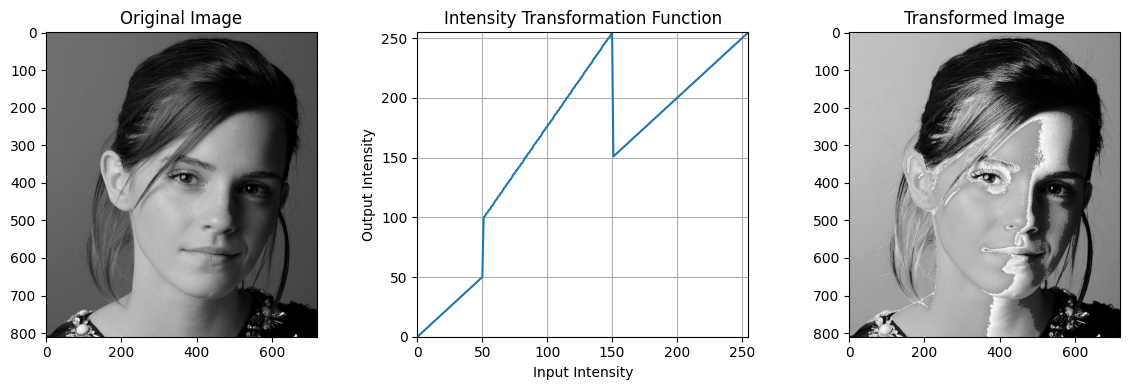

In [2]:
img_emma = cv.imread('./images/emma.jpeg', cv.IMREAD_GRAYSCALE)
assert img_emma is not None

def intensity_transform(im, breakpoints):
    tf = np.zeros(256, dtype=np.uint8)
    for i in range(len(breakpoints) - 1):
        x_start, y_start = breakpoints[i]
        x_end, y_end = breakpoints[i + 1]
        x = np.arange(x_start, x_end + 1)
        tf[x] = np.linspace(y_start, y_end, num=len(x)).astype('uint8')
    return cv.LUT(im, tf), tf

bp = np.array([(0, 0), (50, 50), (51, 100), (150, 255), (151, 151), (255, 255)])

img_transformed, tf = intensity_transform(img_emma, bp)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img_emma, cmap='gray')
ax[0].set_title('Original Image')
ax[1].plot(tf)
ax[1].set_title('Intensity Transformation Function')
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_xlim([0, 255])
ax[1].set_ylim([0, 255])
ax[1].grid()
ax[2].imshow(img_transformed, cmap='gray')
ax[2].set_title('Transformed Image')
plt.tight_layout()
plt.show()

According to the plot and images above, a certain range of intensities has been brightened. Also the discontinuities in the transformation funtion create sudden intensity jumps. 

We can adjust the transformation function to achieve much more visually pleasing results as follows.

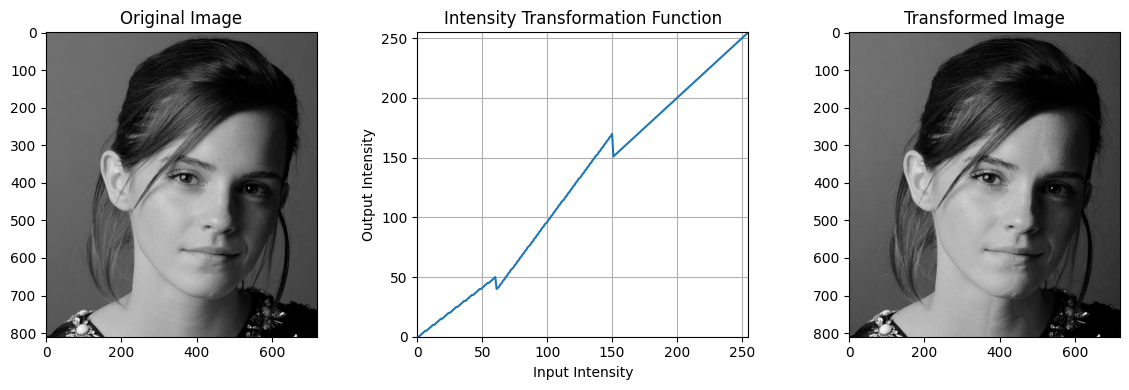

In [3]:
bp = np.array([(0, 0), (60, 50), (61, 40), (150, 170), (151, 151), (255, 255)])

img_transformed, tf = intensity_transform(img_emma, bp)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img_emma, cmap='gray')
ax[0].set_title('Original Image')
ax[1].plot(tf)
ax[1].set_title('Intensity Transformation Function')
ax[1].set_xlabel('Input Intensity')
ax[1].set_ylabel('Output Intensity')
ax[1].set_xlim([0, 255])
ax[1].set_ylim([0, 255])
ax[1].grid()
ax[2].imshow(img_transformed, cmap='gray')
ax[2].set_title('Transformed Image')
plt.tight_layout()
plt.show()

#### Q2. Intensity tranformations on 'brain' 

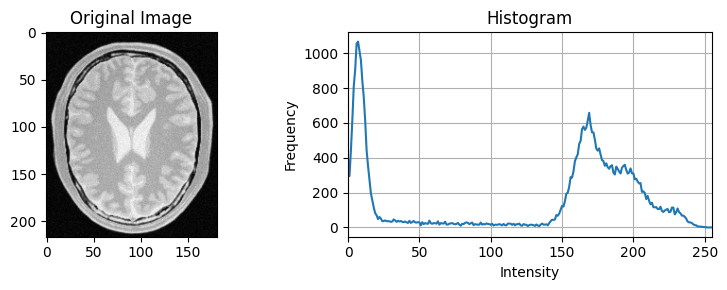

In [4]:
img_brain = cv.imread("./images/brain.jpeg", cv.IMREAD_GRAYSCALE)
assert img_brain is not None

hist = cv.calcHist([img_brain], [0], None, [256], [0, 256])

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].imshow(img_brain, cmap='gray')
ax[0].set_title('Original Image')
ax[1].plot(hist)
ax[1].set_title('Histogram')
ax[1].set_xlabel('Intensity')
ax[1].set_ylabel('Frequency')
ax[1].set_xlim([0, 255])
ax[1].grid()
plt.tight_layout()
plt.show()

According to the intensity histogram, white matter has intensities greater than ~180 and gray matter intensity region spans from ~140-180.

**Extracting white matter**

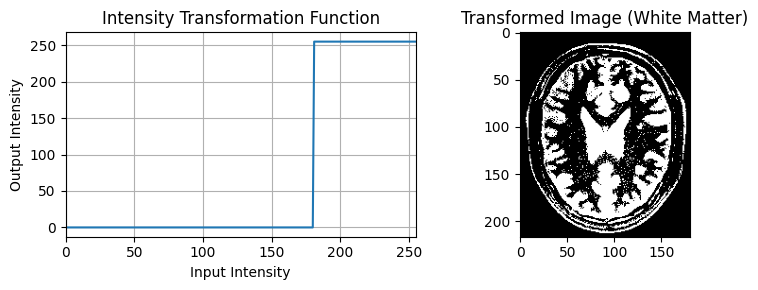

In [5]:
bp = np.array([(0, 0), (180, 0), (181, 255), (255, 255)])

white_matter, tf = intensity_transform(img_brain, bp)

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].plot(tf)
ax[0].set_title('Intensity Transformation Function')
ax[0].set_xlabel('Input Intensity')
ax[0].set_ylabel('Output Intensity')
ax[0].set_xlim([0, 255])
ax[0].grid()
ax[1].imshow(white_matter, cmap='gray')
ax[1].set_title('Transformed Image (White Matter)')
plt.tight_layout()
plt.show()

**Extracting gray matter**

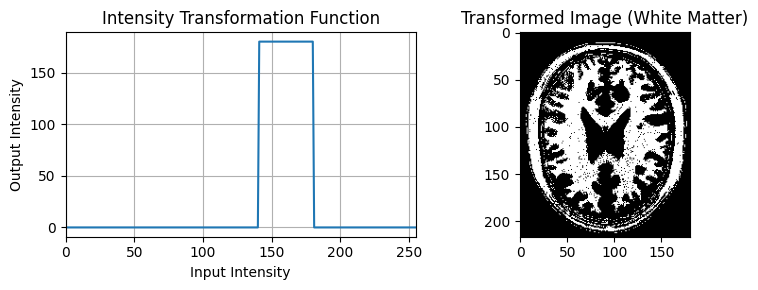

In [6]:
bp = np.array([(0, 0), (140, 0), (141, 180), (180, 180), (181, 0), (255, 0)])

white_matter, tf = intensity_transform(img_brain, bp)

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].plot(tf)
ax[0].set_title('Intensity Transformation Function')
ax[0].set_xlabel('Input Intensity')
ax[0].set_ylabel('Output Intensity')
ax[0].set_xlim([0, 255])
ax[0].grid()
ax[1].imshow(white_matter, cmap='gray')
ax[1].set_title('Transformed Image (White Matter)')
plt.tight_layout()
plt.show()

#### Q3. Gamma correction

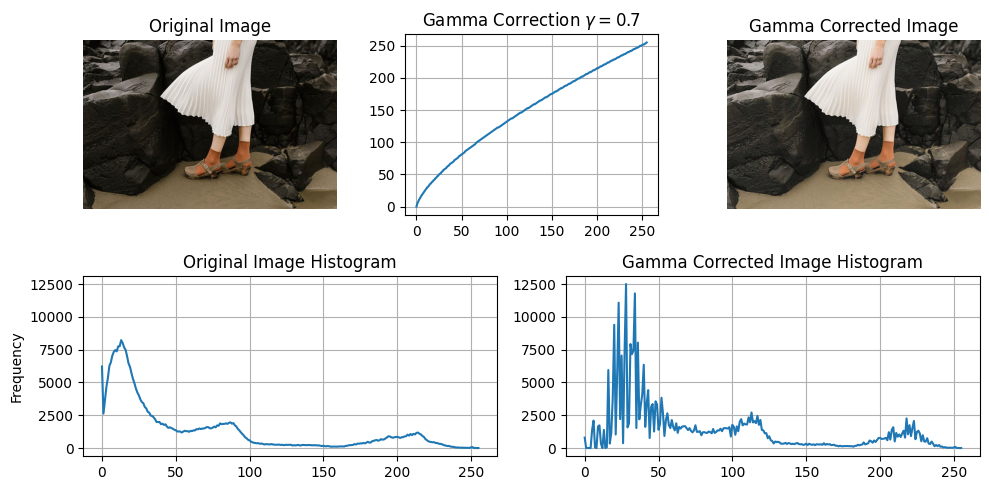

In [7]:
img_beach = cv.imread("./images/beach.jpeg", cv.IMREAD_COLOR)
assert img_beach is not None

img_lab = cv.cvtColor(img_beach, cv.COLOR_BGR2LAB)

gamma = 0.7
t = np.array([((i / 255.0) ** gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
img_lab[:, :, 0] = cv.LUT(img_lab[:, :, 0], t)
img_corrected = cv.cvtColor(img_lab, cv.COLOR_LAB2BGR)

hist_original = cv.calcHist([img_beach], [0], None, [256], [0, 256])
hist_gamma_corrected = cv.calcHist([img_corrected], [0], None, [256], [0, 256])

fig = plt.figure(figsize=(10, 5))
gs = fig.add_gridspec(2, 6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
ax4 = fig.add_subplot(gs[1, 0:3])
ax5 = fig.add_subplot(gs[1, 3:6], sharey=ax4)

ax1.imshow(cv.cvtColor(img_beach, cv.COLOR_BGR2RGB))
ax1.set_title("Original Image")
ax1.axis("off")
ax2.plot(t)
ax2.set_title(fr"Gamma Correction $\gamma = {gamma}$")
ax3.imshow(cv.cvtColor(img_corrected, cv.COLOR_BGR2RGB))
ax3.set_title("Gamma Corrected Image")
ax3.axis("off")
ax4.plot(hist_original)
ax4.set_title("Original Image Histogram")
ax5.plot(hist_gamma_corrected)
ax5.set_title("Gamma Corrected Image Histogram")
ax4.set_ylabel("Frequency")
for ax in [ax2, ax4, ax5]:
    ax.grid()
plt.tight_layout()
plt.show()

Dark regions have been brightened to enhance shadows.

#### Q4. Increasing the vibrance

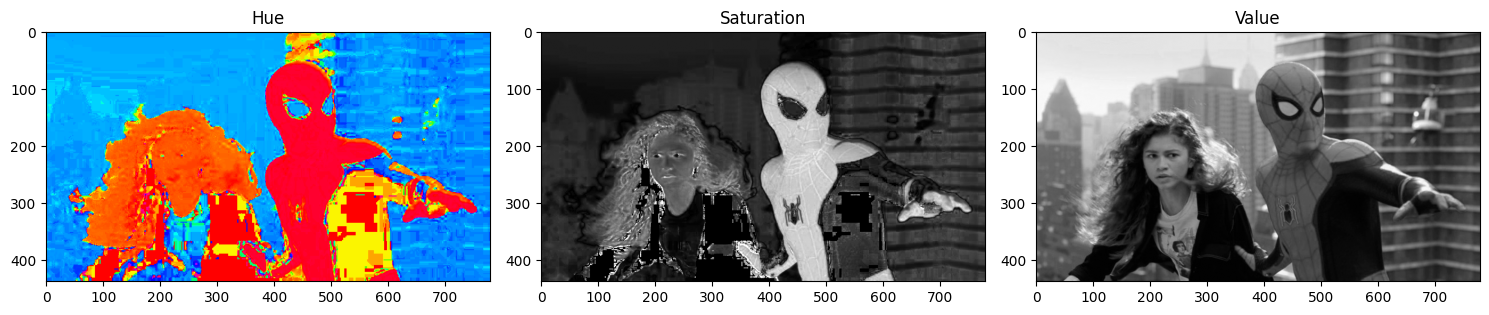

In [8]:
img_spidey = cv.imread("./images/spidey.jpeg", cv.IMREAD_COLOR)
assert img_spidey is not None

h, s, v = cv.split(cv.cvtColor(img_spidey, cv.COLOR_BGR2HSV))

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(h, cmap='hsv')
ax[1].imshow(s, cmap='gray')
ax[2].imshow(v, cmap='gray')
ax[0].set_title('Hue')
ax[1].set_title('Saturation')
ax[2].set_title('Value')
plt.tight_layout()
plt.show()

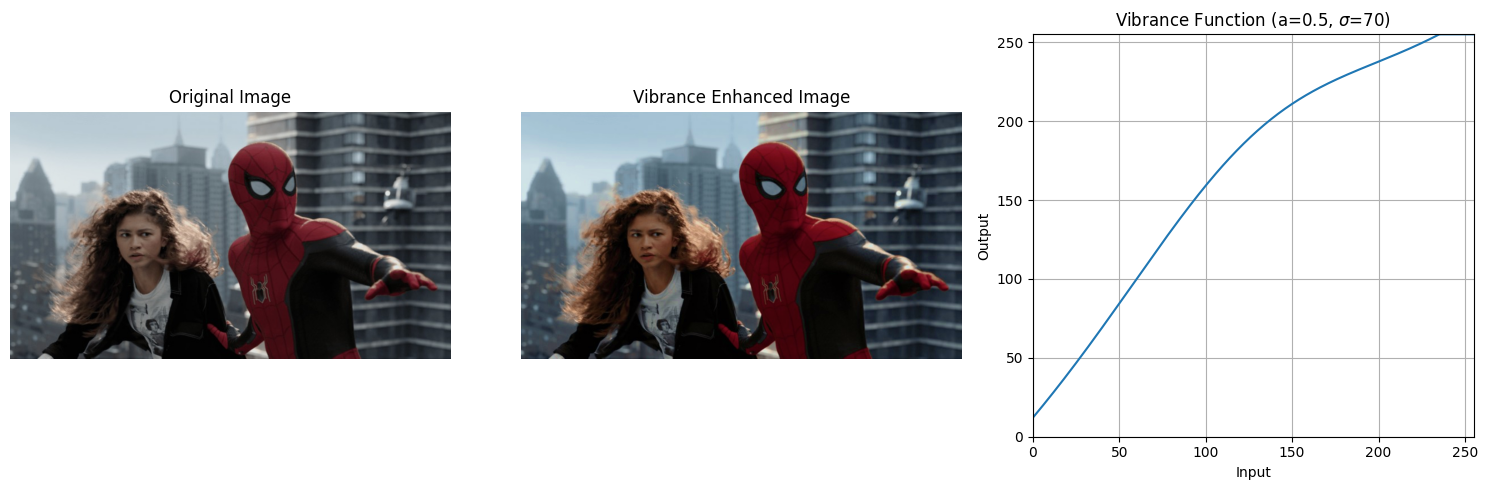

In [9]:
def f(x, a, sigma):
    return np.minimum(x + a * 128 * np.exp( -1 * ((x - 128) ** 2) / (2 * (sigma ** 2))), 255)

a = 0.5; sigma = 70

processed_s = f(s.astype(np.float32), a, sigma).astype(np.uint8)
hsv_corrected = cv.merge([h, processed_s, v])

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(cv.cvtColor(img_spidey, cv.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[1].imshow(cv.cvtColor(hsv_corrected, cv.COLOR_HSV2RGB))
ax[1].set_title('Vibrance Enhanced Image')
ax[2].plot(f(np.arange(256), a, sigma))
ax[2].set_title(fr'Vibrance Function (a={a}, $\sigma$={sigma})')
ax[2].set_xlabel('Input')
ax[2].set_ylabel('Output')
ax[2].set_xlim([0, 255])
ax[2].set_ylim([0, 255])
ax[2].grid()
for a in [ax[0], ax[1]]:
    a.axis('off')
plt.tight_layout()
plt.show()

#### Q5. Histogram equalization

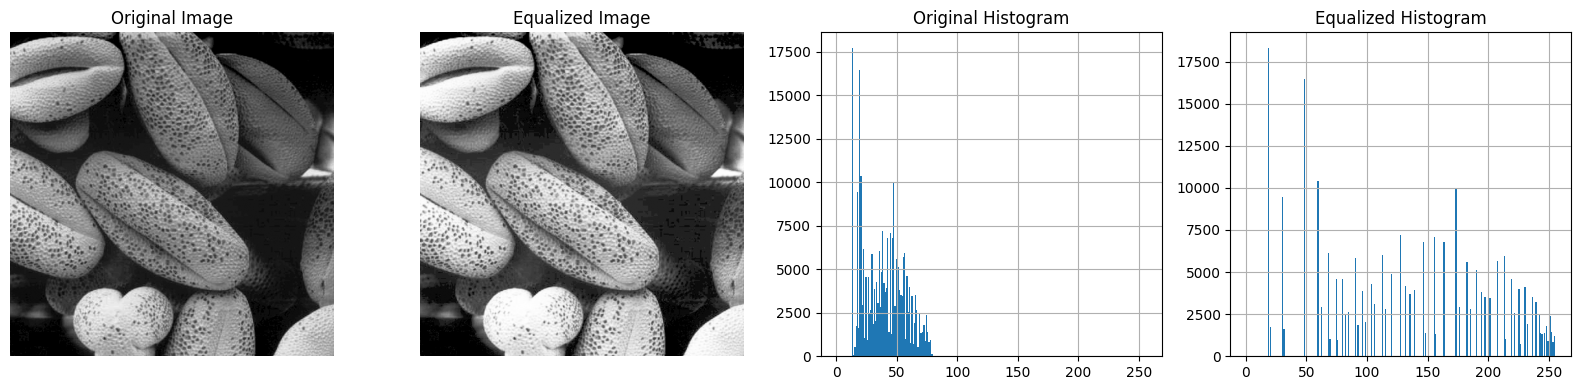

In [10]:
img_shells = cv.imread("./images/shells.tif", cv.IMREAD_GRAYSCALE)
assert img_shells is not None

def equal_hist(im):
    L = np.iinfo(im.dtype).max + 1
    M, N = im.shape
    cdf = np.histogram(im, bins=256, range=[0, 256])[0].cumsum()
    t = np.array([(L-1) / (M*N) * cdf[k] for k in range(256)]).astype('uint8')
    return t[im]

equalized_shells = equal_hist(img_shells)

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(img_shells, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(equalized_shells, cmap='gray')
ax[1].set_title('Equalized Image')
ax[1].axis('off')
ax[2].hist(img_shells.ravel(), bins=256, range=[0, 256])
ax[2].set_title('Original Histogram')
ax[2].grid()
ax[3].hist(equalized_shells.ravel(), bins=256, range=[0, 256])
ax[3].set_title('Equalized Histogram')
ax[3].grid()
plt.tight_layout()
plt.show()

#### Q6. Histogram equalizing the foreground

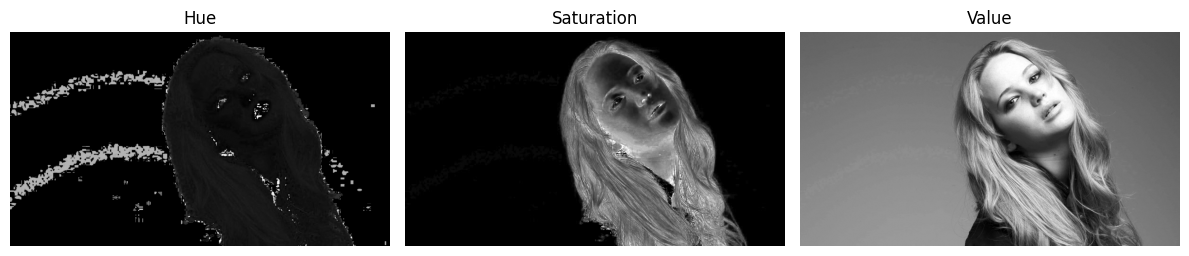

In [11]:
img_jennifer = cv.imread("./images/jennifer.jpeg", cv.IMREAD_COLOR)
assert img_jennifer is not None

h, s, v = cv.split(cv.cvtColor(img_jennifer, cv.COLOR_BGR2HSV))

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(h, cmap='gray')
ax[0].set_title('Hue')
ax[1].imshow(s, cmap='gray')
ax[1].set_title('Saturation')
ax[2].imshow(v, cmap='gray')
ax[2].set_title('Value')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

The **saturation plane** is the most suitable plane to extract the foreground mask.

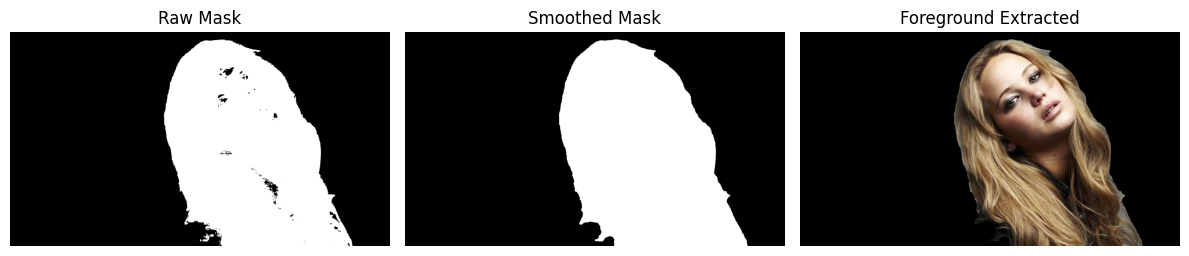

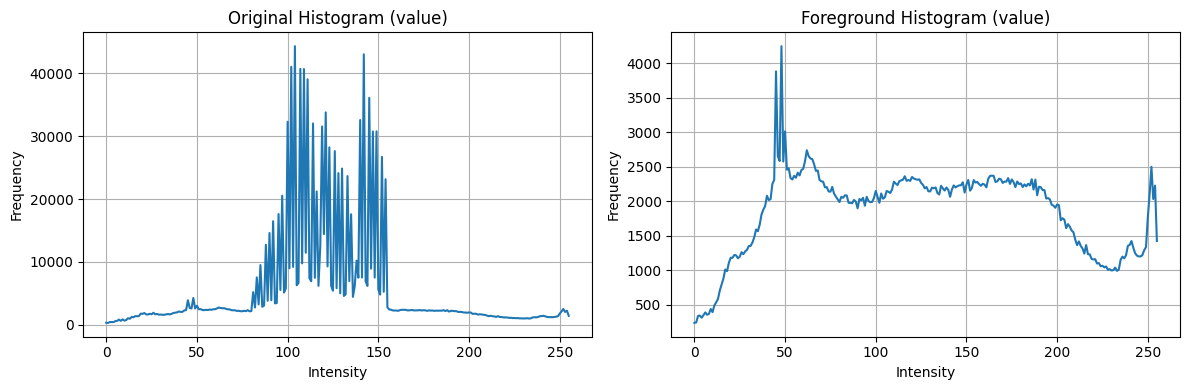

In [12]:
_, mask = cv.threshold(s, 20, 255, cv.THRESH_BINARY)
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (25, 25))
mask_smooth = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel)
foreground = cv.bitwise_and(img_jennifer, img_jennifer, mask=mask_smooth)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(mask, cmap='gray')
ax[0].set_title('Raw Mask')
ax[1].imshow(mask_smooth, cmap='gray')
ax[1].set_title('Smoothed Mask')
ax[2].imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB))
ax[2].set_title('Foreground Extracted')
for a in ax:
    a.axis('off')
plt.tight_layout()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
hist_original = cv.calcHist([v], [0], None, [256], [0, 256])
hist_masked = cv.calcHist([v], [0], mask_smooth, [256], [0, 256])
ax[0].plot(hist_original)
ax[0].set_title('Original Histogram (value)')
ax[1].plot(hist_masked)
ax[1].set_title('Foreground Histogram (value)')
for a in ax:
    a.grid()
    a.set_xlabel('Intensity')
    a.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

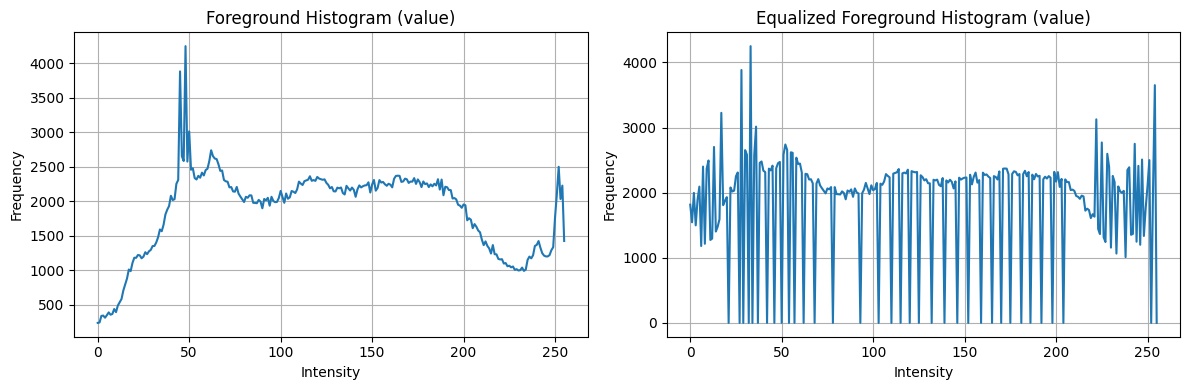

In [13]:
M, N = v.shape
cdf = np.cumsum(hist_masked).flatten()
t = np.array([(255 / cdf[-1]) * cdf[k] for k in range(256)]).astype('uint8')
v_equalized = v.copy()
v_equalized[mask_smooth > 0] = t[v[mask_smooth > 0]]
hist_v_equalized = cv.calcHist([v_equalized], [0], mask_smooth, [256], [0, 256])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist_masked)
ax[0].set_title('Foreground Histogram (value)')
ax[1].plot(hist_v_equalized)
ax[1].set_title('Equalized Foreground Histogram (value)')
for a in ax:
    a.grid()
    a.set_xlabel('Intensity')
    a.set_ylabel('Frequency')
plt.tight_layout()
plt.show()


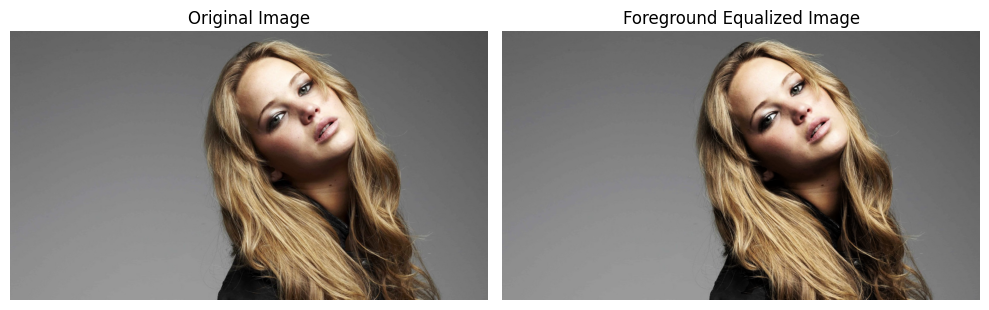

In [14]:
equalized_hsv = cv.merge([h, s, v_equalized])

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(cv.cvtColor(img_jennifer, cv.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[1].imshow(cv.cvtColor(equalized_hsv, cv.COLOR_HSV2RGB))
ax[1].set_title('Foreground Equalized Image')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

#### Q7. Sobel filtering

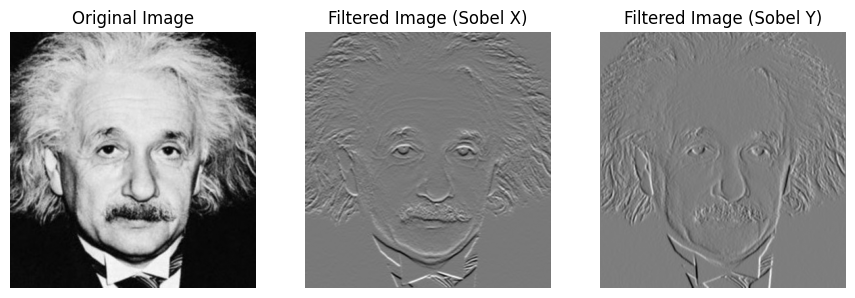

In [15]:
img_einstein = cv.imread("./images/einstein.jpeg", cv.IMREAD_GRAYSCALE)
assert img_einstein is not None

sobel_x = np.array([[1,2,1], [0,0,0], [-1,-2,-1]])
sobel_y = np.array([[1,0,-1], [2,0,-2], [1,0,-1]])
filtered_img_x = cv.filter2D(img_einstein, cv.CV_64F, sobel_x)
filtered_img_y = cv.filter2D(img_einstein, cv.CV_64F, sobel_y)

fig, ax = plt.subplots(1, 3, figsize=(9, 3))
ax[0].imshow(img_einstein, cmap='gray')
ax[0].set_title('Original Image')
ax[1].imshow(filtered_img_x, cmap='gray')
ax[1].set_title('Filtered Image (Sobel X)')
ax[2].imshow(filtered_img_y, cmap='gray')
ax[2].set_title('Filtered Image (Sobel Y)')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

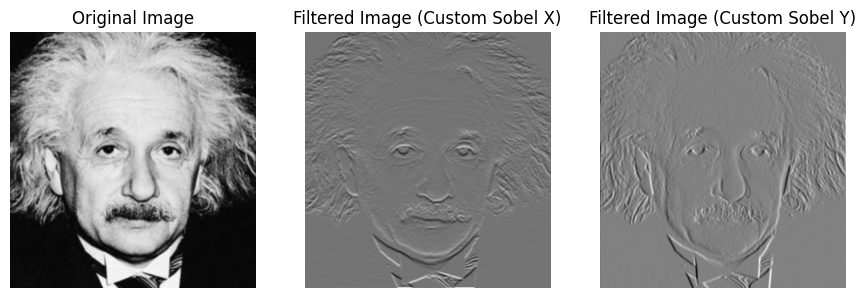

In [16]:
def sobel_filter(im, kernel):
    im_h, im_w = im.shape
    k_h, k_w = kernel.shape
    padded_img = np.pad(im, ((k_h//2, k_h//2), (k_w//2, k_w//2)), mode='constant', constant_values=0)
    filtered_img = np.zeros((im_h, im_w), dtype=np.float64)
    for i in range(im_h):
        for j in range(im_w):
            region = padded_img[i:i+k_h, j:j+k_w]
            filtered_img[i, j] = np.sum(region * kernel)
    return filtered_img

filtered_img_custom_x = sobel_filter(img_einstein, sobel_x)
filtered_img_custom_y = sobel_filter(img_einstein, sobel_y)

fig, ax = plt.subplots(1, 3, figsize=(9, 3))
ax[0].imshow(img_einstein, cmap='gray')
ax[0].set_title('Original Image')
ax[1].imshow(filtered_img_custom_x, cmap='gray')
ax[1].set_title('Filtered Image (Custom Sobel X)')
ax[2].imshow(filtered_img_custom_y, cmap='gray')
ax[2].set_title('Filtered Image (Custom Sobel Y)')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()


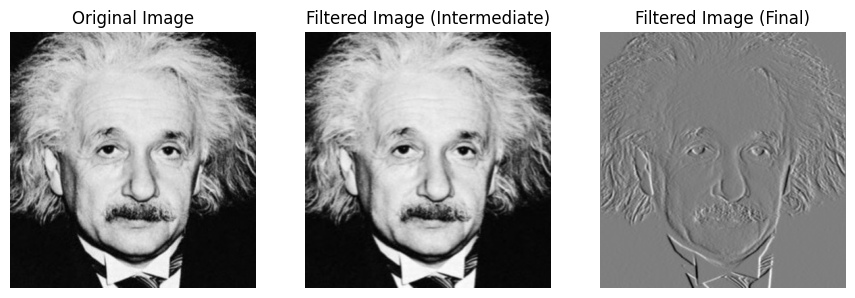

In [17]:
sobel_h1 = np.array([1, 2, 1])
sobel_h2 = np.array([1, 0, -1])

filter_intermediate = cv.filter2D(img_einstein, cv.CV_64F, sobel_h1)
filtered_img = cv.filter2D(filter_intermediate, cv.CV_64F, sobel_h2)

fig, ax = plt.subplots(1, 3, figsize=(9, 3))
ax[0].imshow(img_einstein, cmap='gray')
ax[0].set_title('Original Image')
ax[1].imshow(filter_intermediate, cmap='gray')
ax[1].set_title('Filtered Image (Intermediate)')
ax[2].imshow(filtered_img, cmap='gray')
ax[2].set_title('Filtered Image (Final)')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

#### Q8. Zooming

In [18]:
im01 = cv.imread("./images/im01.png", cv.IMREAD_COLOR)
im01small = cv.imread("./images/im01small.png", cv.IMREAD_COLOR)
im02 = cv.imread("./images/im02.png", cv.IMREAD_COLOR)
im02small = cv.imread("./images/im02small.png", cv.IMREAD_COLOR)
im03 = cv.imread("./images/im03.png", cv.IMREAD_COLOR)
im03small = cv.imread("./images/im03small.png", cv.IMREAD_COLOR)
taylor = cv.imread("./images/taylor.jpg", cv.IMREAD_COLOR)
taylor_small = cv.imread("./images/taylor_small.jpg", cv.IMREAD_COLOR)
taylor_very_small = cv.imread("./images/taylor_very_small.jpg", cv.IMREAD_COLOR)

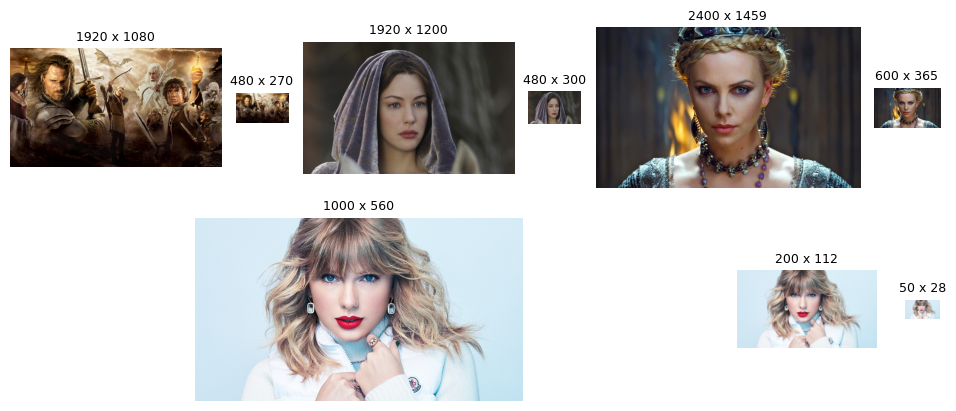

In [47]:
images = [im01, im01small, im02, im02small, im03, im03small, taylor, taylor_small, taylor_very_small]

im_widths = [img.shape[1] for img in images]
fig = plt.figure(figsize=(12, 5))
grid = fig.add_gridspec(2, 1, hspace=0.1)
gs1 = grid[0].subgridspec(1, 6, width_ratios=im_widths[:6], wspace=0.1)
gs2 = grid[1].subgridspec(1, 3, width_ratios=im_widths[6:], wspace=0.1)

for i, img in enumerate(images[:6]):
    ax = fig.add_subplot(gs1[0, i])
    ax.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    ax.set_title(f"{img.shape[1]} x {img.shape[0]}", fontsize=9)
    ax.axis("off")

for i, img in enumerate(images[6:]):
    ax = fig.add_subplot(gs2[0, i])
    ax.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    ax.set_title(f"{img.shape[1]} x {img.shape[0]}", fontsize=9)
    ax.axis("off")

plt.show()

In [20]:
def nn_interp(img, scale_factor):
    """Nearest Neighbor Interpolation"""
    im_h, im_w = img.shape[:2]
    new_h = int(im_h * scale_factor)
    new_w = int(im_w * scale_factor)
    scaled_img = np.zeros((new_h, new_w) + img.shape[2:], dtype=img.dtype)
    src_i = np.minimum((np.arange(new_h) / scale_factor).astype(int), im_h - 1)
    src_j = np.minimum((np.arange(new_w) / scale_factor).astype(int), im_w - 1)
    for i in range(new_h):
        for j in range(new_w):
            scaled_img[i, j] = img[src_i[i], src_j[j]]
    return scaled_img

def bl_interp(img, scale_factor):
    """Bilinear Interpolation"""
    im_h, im_w = img.shape[:2]
    new_h = int(im_h * scale_factor)
    new_w = int(im_w * scale_factor)
    scaled_img = np.zeros((new_h, new_w) + img.shape[2:], dtype=img.dtype)
    for i in range(new_h):
        src_i = i / scale_factor
        i0 = int(np.floor(src_i))
        i1 = min(i0 + 1, im_h - 1)
        dy = src_i - i0
        for j in range(new_w):
            src_j = j / scale_factor
            j0 = int(np.floor(src_j))
            j1 = min(j0 + 1, im_w - 1)
            dx = src_j - j0
            A = img[i0, j0]
            B = img[i0, j1]
            C = img[i1, j0]
            D = img[i1, j1]
            scaled_img[i, j] = (A * (1 - dx) * (1 - dy) + B * dx * (1 - dy) + C * (1 - dx) * dy + D * dx * dy).astype(img.dtype)
    return scaled_img

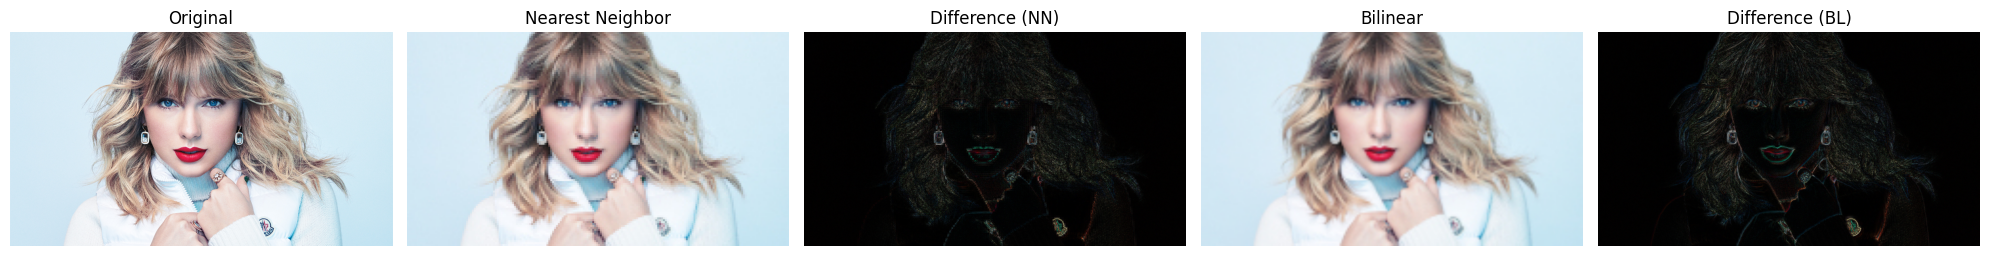

In [21]:
scaled_taylor_nn = nn_interp(taylor_small, 5)
scaled_taylor_bl = bl_interp(taylor_small, 5)

fig, ax = plt.subplots(1, 5, figsize=(20, 4))
ax[0].imshow(cv.cvtColor(taylor, cv.COLOR_BGR2RGB))
ax[0].set_title("Original")
ax[1].imshow(cv.cvtColor(scaled_taylor_nn, cv.COLOR_BGR2RGB))
ax[1].set_title("Nearest Neighbor")
diff_nn = cv.absdiff(taylor, scaled_taylor_nn)
ax[2].imshow(cv.cvtColor(diff_nn, cv.COLOR_BGR2RGB))
ax[2].set_title("Difference (NN)")
ax[3].imshow(cv.cvtColor(scaled_taylor_bl, cv.COLOR_BGR2RGB))
ax[3].set_title("Bilinear")
diff_bl = cv.absdiff(taylor, scaled_taylor_bl)
ax[4].imshow(cv.cvtColor(diff_bl, cv.COLOR_BGR2RGB))
ax[4].set_title("Difference (BL)")
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()


In [22]:
def ssd(img1, img2):
    """Sum of Squared Differences"""
    h, w = np.minimum(img1.shape, img2.shape)[:2]
    img1 = img1[:h, :w]
    img2 = img2[:h, :w]
    return np.sum((img1.astype(np.float32) - img2.astype(np.float32)) ** 2)

original_images = [im01, im02, im03, taylor, taylor]
small_images = [im01small, im02small, im03small, taylor_small, taylor_very_small]
scale_factors = [original_images[i].shape[1] / small_images[i].shape[1] for i in range(len(original_images))]
print("Scale Factors:", scale_factors)

scaled_images_nn = [nn_interp(img, scale_factor) for img, scale_factor in zip(small_images, scale_factors)]
scaled_images_bl = [bl_interp(img, scale_factor) for img, scale_factor in zip(small_images, scale_factors)]

ssd_nn = [ssd(original, scaled) for original, scaled in zip(original_images, scaled_images_nn)]
ssd_bl = [ssd(original, scaled) for original, scaled in zip(original_images, scaled_images_bl)]

print("SSD (Nearest Neighbor):", ssd_nn)
print("SSD (Bilinear):", ssd_bl)

Scale Factors: [4.0, 4.0, 4.0, 5.0, 20.0]
SSD (Nearest Neighbor): [np.float32(8.4770246e+08), np.float32(1.8279536e+08), np.float32(7.0993184e+08), np.float32(3.998873e+08), np.float32(8.1629594e+08)]
SSD (Bilinear): [np.float32(1.245685e+09), np.float32(3.3841613e+08), np.float32(1.03012506e+09), np.float32(4.7904096e+08), np.float32(1.0997334e+09)]


#### Q9. GrabCut

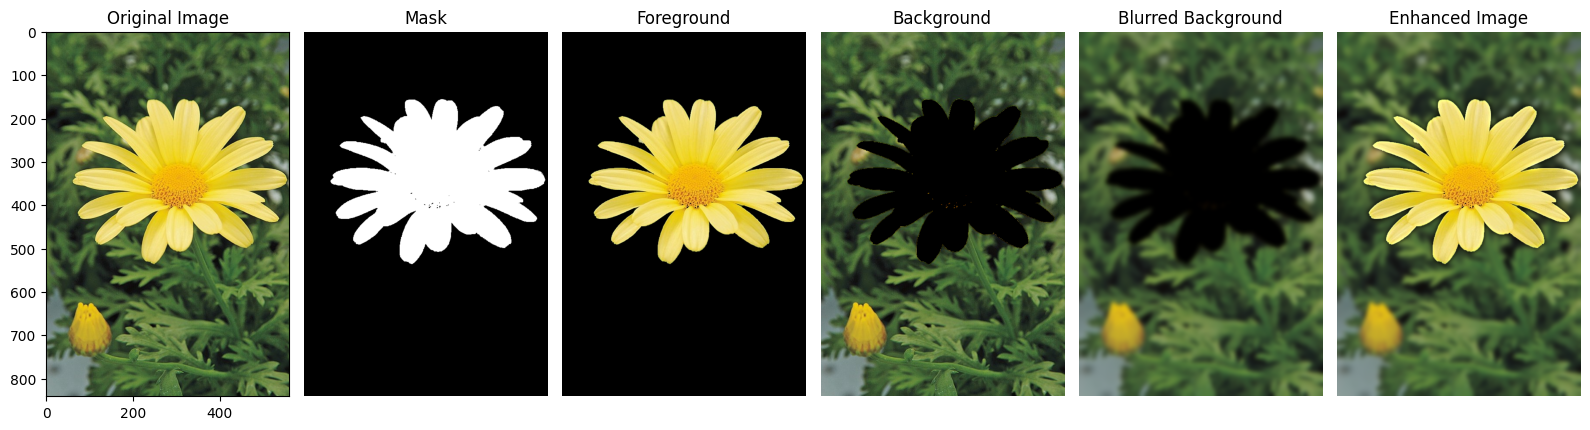

In [23]:
img_flower = cv.imread("./images/flower.jpeg", cv.IMREAD_COLOR)
assert img_flower is not None

mask = np.zeros(img_flower.shape[:2], dtype=np.uint8)

bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

rect = (0, 100, img_flower.shape[1], 500)
cv.grabCut(img_flower, mask, rect, bgdModel, fgdModel, 5, cv.GC_INIT_WITH_RECT)

mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')
foreground = img_flower * mask2[:, :, np.newaxis]
background = img_flower * (1 - mask2[:, :, np.newaxis])

blurred_bgd = cv.GaussianBlur(background, (31, 31), 0)
enhanced_image = cv.add(foreground, blurred_bgd)

fig, ax = plt.subplots(1, 6, figsize=(16, 4))
ax[0].imshow(cv.cvtColor(img_flower, cv.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[1].imshow(mask2, cmap='gray')
ax[1].set_title('Mask')
ax[2].imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB))
ax[2].set_title('Foreground')
ax[3].imshow(cv.cvtColor(background, cv.COLOR_BGR2RGB))
ax[3].set_title('Background')
ax[4].imshow(cv.cvtColor(blurred_bgd, cv.COLOR_BGR2RGB))
ax[4].set_title('Blurred Background')
ax[5].imshow(cv.cvtColor(enhanced_image, cv.COLOR_BGR2RGB))
ax[5].set_title('Enhanced Image')
for a in ax[1:]:
    a.axis('off')
plt.tight_layout()
plt.show()

The background just beyond the edge of the flower appears darker in the enhanced image because the Gaussian blur includes black pixels corresponding to the removed foreground when averaging pixels near the flower boundary.

#### Q10. Bilateral filter

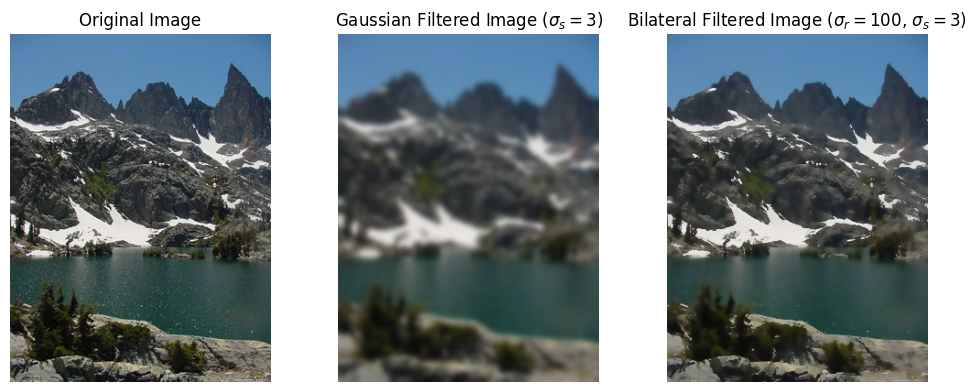

In [24]:
img_lake = cv.imread("./images/lake.jpeg", cv.IMREAD_COLOR)
assert img_lake is not None

sigma_s = 3
sigma_r = 100

gaussian_filtered = cv.GaussianBlur(img_lake, (0, 0), sigmaX=sigma_s, sigmaY=sigma_s)
bilateral_filtered = cv.bilateralFilter(img_lake, d=0, sigmaColor=sigma_r, sigmaSpace=sigma_s)

fig, ax = plt.subplots(1, 3, figsize=(10, 4))
ax[0].imshow(cv.cvtColor(img_lake, cv.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[1].imshow(cv.cvtColor(gaussian_filtered, cv.COLOR_BGR2RGB))
ax[1].set_title(fr'Gaussian Filtered Image ($\sigma_s={sigma_s}$)')
ax[2].imshow(cv.cvtColor(bilateral_filtered, cv.COLOR_BGR2RGB))
ax[2].set_title(fr'Bilateral Filtered Image ($\sigma_r={sigma_r}$, $\sigma_s={sigma_s}$)')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

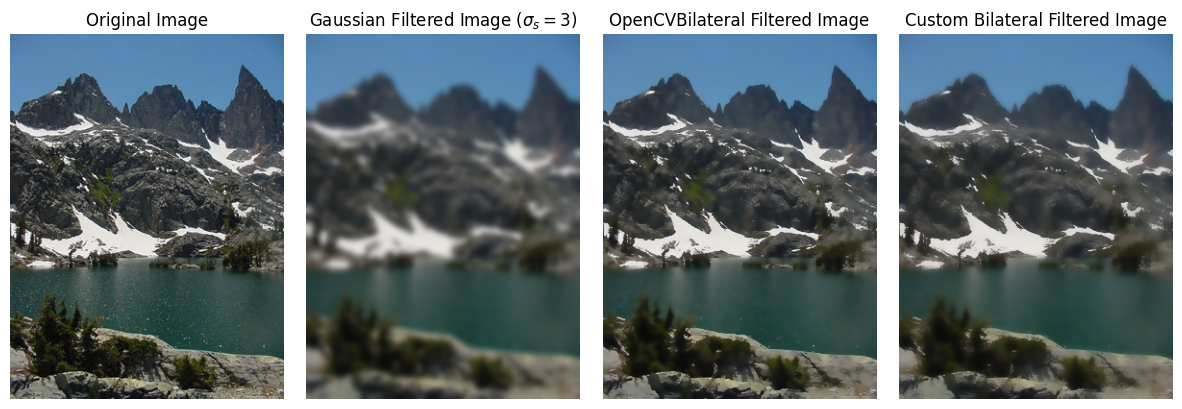

In [25]:
def bl_filter(im, sigma_s, sigma_r):
    """Custom Bilateral Filter"""
    im = im.astype(np.float32)
    im_h, im_w = im.shape[:2]
    filtered_img = np.zeros((im_h, im_w, im.shape[2]), dtype=np.float32)
    radius = int(3 * sigma_s)
    padded_img = np.pad(im, ((radius, radius), (radius, radius), (0, 0)), mode='reflect')
    x, y = np.meshgrid(np.arange(-radius, radius + 1), np.arange(-radius, radius + 1))
    spatial_weights = np.exp(-(x**2 + y**2) / (2 * sigma_s**2))
    for i in range(im_h):
        for j in range(im_w):
            region = padded_img[i:i + 2 * radius + 1, j:j + 2 * radius + 1]
            center = padded_img[i + radius, j + radius]
            range_weights = np.exp(-np.sum((region - center) ** 2, axis=2) / (2 * sigma_r**2))
            weights = spatial_weights * range_weights
            weights /= np.sum(weights)
            filtered_img[i, j] = np.sum(region * weights[:, :, np.newaxis], axis=(0, 1))
    return filtered_img

custom_bilateral_filtered = bl_filter(img_lake, sigma_s, sigma_r)

fig, ax = plt.subplots(1, 4, figsize=(12, 4))
ax[0].imshow(cv.cvtColor(img_lake, cv.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[1].imshow(cv.cvtColor(gaussian_filtered, cv.COLOR_BGR2RGB))
ax[1].set_title(fr'Gaussian Filtered Image ($\sigma_s={sigma_s}$)')
ax[2].imshow(cv.cvtColor(bilateral_filtered, cv.COLOR_BGR2RGB))
ax[2].set_title('OpenCVBilateral Filtered Image')
ax[3].imshow(cv.cvtColor(custom_bilateral_filtered.astype(np.uint8), cv.COLOR_BGR2RGB))
ax[3].set_title('Custom Bilateral Filtered Image')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

In [26]:
mae = np.mean(np.abs(bilateral_filtered.astype(np.float32) - custom_bilateral_filtered))
mse = np.mean((bilateral_filtered.astype(np.float32) - custom_bilateral_filtered) ** 2) 
print(f"Mean Absolute Error between OpenCV and Custom Bilateral Filter: {mae:.4f}")
print(f"Mean Squared Error between OpenCV and Custom Bilateral Filter: {mse:.4f}")

Mean Absolute Error between OpenCV and Custom Bilateral Filter: 3.6651
Mean Squared Error between OpenCV and Custom Bilateral Filter: 38.8396
